# Prevendo a nota do ENEM com uma rede neural — e o viés que ela aprende

**Pós-graduação em Ciência de Dados — UNIFOR | Disciplina: Redes Neurais**
Autor: Luis Helder Martins Uchoa

## O desafio
Dado **apenas o perfil de um candidato e as respostas do questionário socioeconômico** (renda, escolaridade
dos pais, bens em casa, cor/raça, sexo, idade, UF…), uma rede neural consegue prever a **nota média no ENEM**
(média de Ciências da Natureza, Humanas, Linguagens, Matemática e Redação)?

E a pergunta que realmente importa:

> **Se essa rede for usada para tomar decisões (bolsas, triagem, admissão), quem ela prejudica?**
> Como os dados de treino moldam o viés do modelo?

## Por que dados de 2023 (e não 2025)?
Nos microdados de **2024 e 2025** o INEP separou o questionário (`PARTICIPANTES`) das notas (`RESULTADOS`) em
arquivos **sem chave em comum**, por causa da LGPD. Não é possível ligar o perfil de uma pessoa à nota dela.
**2023 é o último ano com perfil + questionário + notas no mesmo registro**, então é o ano usado para treinar.
Os dados de 2025 entram no final, numa **validação agregada por UF**.

## Roteiro
1. Dados e harmonização 2023 ↔ 2025
2. Análise exploratória
3. Baselines (média, regressão linear e gradient boosting) × **MLP com embeddings (PyTorch)**
4. **Experimento A** — viés do modelo treinado com dados "completos"
5. **Experimento B** — o que acontece quando os dados de treino são enviesados
6. **Experimento C** — mais informação: escola, língua estrangeira e contexto do município (IDHM etc.)
7. **Do diagnóstico à ação** — onde agir antes da prova (áreas, escolas, municípios)
8. Aplicação em 2025 (validação agregada por UF)
9. Conclusões

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads()))
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
CORES = ["#2a6fdb", "#e8833a", "#3aa76d", "#c94f7c", "#7a5cc4", "#8c8c8c"]
DADOS = "dados/"

## 1. Dados e harmonização

A amostra foi gerada pelo script `01_preparar_dados.py`: dos **3,93 milhões** de inscritos em 2023,
**2,59 milhões** fizeram as 4 provas objetivas e tiveram redação válida; desses, foi sorteada uma amostra
aleatória de 15% (~387 mil candidatos).

**Harmonização.** O questionário de 2025 mudou (algumas perguntas saíram, a ordem mudou e itens de contagem
passaram a ter teto "3 ou mais"). Para que o modelo treinado em 2023 possa ser aplicado em 2025, cada
variável é convertida para um **código comum**:

| Variável harmonizada | 2023 | 2025 | Ajuste |
|---|---|---|---|
| Escolaridade pai / mãe | Q001 / Q002 | Q001 / Q002 | idêntico |
| Ocupação pai / mãe | Q003 / Q004 | Q003 / Q004 | idêntico |
| Pessoas na casa | Q005 | Q005 | teto em 8+ |
| Renda familiar (faixas em salários mínimos) | Q006 | Q007 | mesmas 17 faixas em múltiplos do SM |
| Empregada doméstica | Q007 | Q008 | idêntico |
| Banheiros, quartos, carros, motos, geladeiras, TVs | Q008–Q012, Q019 | Q009–Q013, Q018 | 2023 com teto em "3 ou mais" |
| Freezer, máq. lavar, micro-ondas | Q013, Q014, Q016 | Q014–Q016 | vira Sim/Não |
| Aspirador, TV por assinatura, internet | Q018, Q021, Q025 | Q017, Q019, Q020 | idêntico (Sim/Não) |
| Celulares, computadores | Q022, Q024 | Q022, Q021 | idêntico |

Itens que só existem em um dos anos (secadora, lava-louça, DVD, telefone fixo em 2023; "você possui renda?" e tipo
de escola em 2025) ficam de fora. O **tipo de escola (pública/privada) não é usado como entrada**: ele é usado só
para **avaliar** o viés.

In [2]:
def _cap(s, mapa):
    return s.replace(mapa)

PERFIL = ["TP_FAIXA_ETARIA", "TP_SEXO", "TP_ESTADO_CIVIL", "TP_COR_RACA", "TP_NACIONALIDADE",
          "TP_ST_CONCLUSAO", "IN_TREINEIRO", "SG_UF_PROVA"]
TETO3 = {"E": "D"}                      # "quatro ou mais" -> "três ou mais"
BIN = {"C": "B", "D": "B", "E": "B"}    # "sim, dois/três/quatro" -> "sim"

def harmonizar_2023(d):
    h = d[PERFIL].copy()
    h["ESC_PAI"], h["ESC_MAE"] = d.Q001, d.Q002
    h["OCUP_PAI"], h["OCUP_MAE"] = d.Q003, d.Q004
    h["PESSOAS"] = d.Q005.astype(int).clip(upper=8).astype(str)
    h["RENDA"] = d.Q006
    h["EMPREGADA"] = d.Q007
    for novo, q in [("BANHEIRO", "Q008"), ("QUARTOS", "Q009"), ("CARRO", "Q010"), ("MOTO", "Q011"),
                    ("GELADEIRA", "Q012"), ("TV", "Q019")]:
        h[novo] = _cap(d[q], TETO3)
    for novo, q in [("FREEZER", "Q013"), ("MAQ_LAVAR", "Q014"), ("MICROONDAS", "Q016")]:
        h[novo] = _cap(d[q], BIN)
    h["ASPIRADOR"], h["TV_ASSIN"], h["INTERNET"] = d.Q018, d.Q021, d.Q025
    h["CELULAR"], h["COMPUTADOR"] = d.Q022, d.Q024
    return h

def harmonizar_2025(d):
    h = d[PERFIL].copy()
    h["ESC_PAI"], h["ESC_MAE"] = d.Q001, d.Q002
    h["OCUP_PAI"], h["OCUP_MAE"] = d.Q003, d.Q004
    h["PESSOAS"] = pd.to_numeric(d.Q005, errors="coerce").fillna(4).astype(int).clip(upper=8).astype(str)
    h["RENDA"] = d.Q007
    h["EMPREGADA"] = d.Q008
    for novo, q in [("BANHEIRO", "Q009"), ("QUARTOS", "Q010"), ("CARRO", "Q011"), ("MOTO", "Q012"),
                    ("GELADEIRA", "Q013"), ("TV", "Q018")]:
        h[novo] = d[q]
    h["FREEZER"], h["MAQ_LAVAR"], h["MICROONDAS"] = d.Q014, d.Q015, d.Q016
    h["ASPIRADOR"], h["TV_ASSIN"], h["INTERNET"] = d.Q017, d.Q019, d.Q020
    h["CELULAR"], h["COMPUTADOR"] = d.Q022, d.Q021
    return h

raw = pd.read_csv(DADOS + "enem2023_amostra.csv.gz", dtype=str)
NOTAS = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]
for c in NOTAS + ["NOTA_MEDIA"]:
    raw[c] = raw[c].astype(float)

X_all = harmonizar_2023(raw).fillna("NA")
y_all = raw["NOTA_MEDIA"].values.astype(np.float32)
FEATURES = list(X_all.columns)
print(f"{len(raw):,} candidatos | {len(FEATURES)} variáveis de entrada")
print(FEATURES)

387,267 candidatos | 29 variáveis de entrada
['TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 'SG_UF_PROVA', 'ESC_PAI', 'ESC_MAE', 'OCUP_PAI', 'OCUP_MAE', 'PESSOAS', 'RENDA', 'EMPREGADA', 'BANHEIRO', 'QUARTOS', 'CARRO', 'MOTO', 'GELADEIRA', 'TV', 'FREEZER', 'MAQ_LAVAR', 'MICROONDAS', 'ASPIRADOR', 'TV_ASSIN', 'INTERNET', 'CELULAR', 'COMPUTADOR']


### Grupos usados para medir viés
Essas variáveis **não** são todas entradas do modelo; servem para fatiar os erros.

In [3]:
REGIAO = {**dict.fromkeys(["AC","AP","AM","PA","RO","RR","TO"], "Norte"),
          **dict.fromkeys(["AL","BA","CE","MA","PB","PE","PI","RN","SE"], "Nordeste"),
          **dict.fromkeys(["DF","GO","MT","MS"], "Centro-Oeste"),
          **dict.fromkeys(["ES","MG","RJ","SP"], "Sudeste"),
          **dict.fromkeys(["PR","RS","SC"], "Sul")}
def faixa_renda(q):
    return pd.Series(q).map(lambda r: "até 1 SM" if r in "AB" else "1–2 SM" if r in "CD"
                            else "2–4 SM" if r in "EFG" else "4–7 SM" if r in "HIJ" else "> 7 SM")
ORD_RENDA = ["até 1 SM", "1–2 SM", "2–4 SM", "4–7 SM", "> 7 SM"]

G = pd.DataFrame({
    "Renda familiar": faixa_renda(raw.Q006.values).values,
    "Escola (EM)": raw.TP_ESCOLA.map({"1": "Não informou", "2": "Pública", "3": "Privada"}).values,
    "Cor/raça": raw.TP_COR_RACA.map({"0": "Não declarado", "1": "Branca", "2": "Preta", "3": "Parda",
                                     "4": "Amarela", "5": "Indígena", "6": "Não declarado"}).values,
    "Região": raw.SG_UF_PROVA.map(REGIAO).values,
    "Sexo": raw.TP_SEXO.map({"F": "Feminino", "M": "Masculino"}).values,
})
ORDENS = {"Renda familiar": ORD_RENDA, "Escola (EM)": ["Pública", "Privada", "Não informou"],
          "Cor/raça": ["Branca", "Amarela", "Parda", "Preta", "Indígena", "Não declarado"],
          "Região": ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"], "Sexo": ["Feminino", "Masculino"]}
G["Renda familiar"].value_counts(normalize=True).reindex(ORD_RENDA).round(3)

Renda familiar
até 1 SM    0.342
1–2 SM      0.266
2–4 SM      0.204
4–7 SM      0.092
> 7 SM      0.097
Name: proportion, dtype: float64

## 2. Análise exploratória

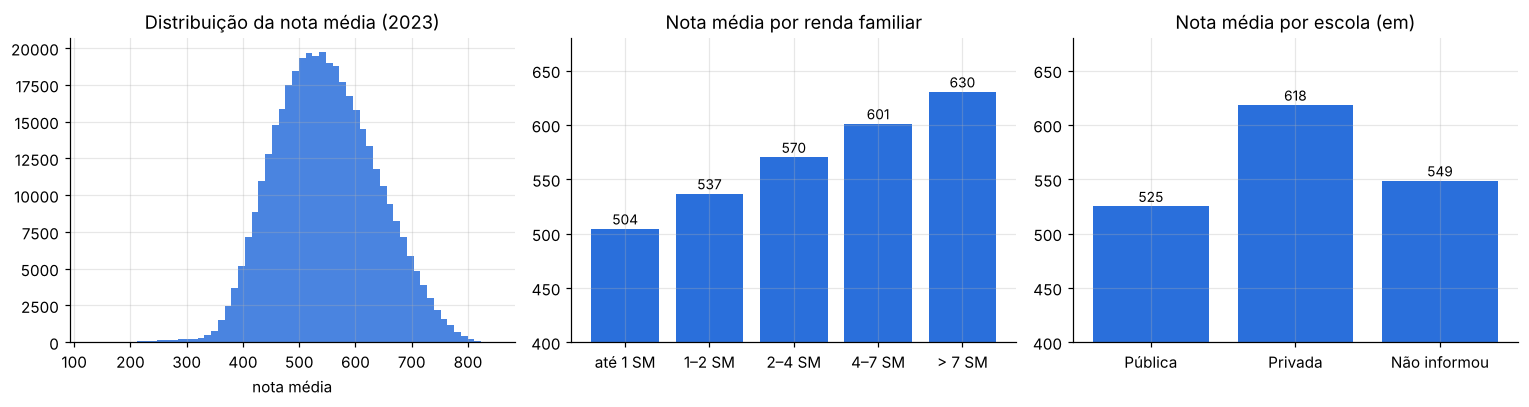

Correlação de Spearman entre faixa de renda (A..Q) e nota: 0.46


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].hist(y_all, bins=60, color=CORES[0], alpha=.85)
axes[0].set_title("Distribuição da nota média (2023)"); axes[0].set_xlabel("nota média")
for ax, g in zip(axes[1:], ["Renda familiar", "Escola (EM)"]):
    m = pd.Series(y_all).groupby(G[g]).mean().reindex(ORDENS[g]).dropna()
    ax.bar(m.index, m.values, color=CORES[0]); ax.set_ylim(400, 680)
    ax.set_title(f"Nota média por {g.lower()}")
    for i, v in enumerate(m.values): ax.text(i, v + 4, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print("Correlação de Spearman entre faixa de renda (A..Q) e nota:",
      round(pd.Series(raw.Q006.map(ord)).corr(pd.Series(y_all), method="spearman"), 3))

A desigualdade já está nos dados: quem tem renda familiar de até 1 salário mínimo fica, em média, cerca de
**125 pontos** abaixo de quem tem mais de 7 SM. Qualquer modelo treinado aqui vai aprender essa relação. A pergunta é **o que ele faz
com quem foge da média do próprio grupo**.

## 3. Modelos

Divisão: **70% treino / 15% validação (early stopping) / 15% teste**.

Baselines de ML tradicional:
- **Média global** — piso: prever a mesma nota para todos.
- **Regressão linear (Ridge)** — variáveis em one-hot; captura só efeitos aditivos.
- **Gradient boosting (HistGradientBoostingRegressor)** — árvores de decisão em sequência, com suporte nativo a
  categóricas; captura interações e não linearidades. Em dados tabulares é o "rival" mais forte de uma rede neural.

In [5]:
idx = np.arange(len(X_all))
i_tr, i_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
i_va, i_te = train_test_split(i_tmp, test_size=0.50, random_state=SEED)
print(f"treino {len(i_tr):,} | validação {len(i_va):,} | teste {len(i_te):,}")

def metricas(y, p):
    return {"MAE": mean_absolute_error(y, p), "RMSE": mean_squared_error(y, p) ** .5, "R²": r2_score(y, p)}

resultados = {}
resultados["Média global"] = metricas(y_all[i_te], np.full(len(i_te), y_all[i_tr].mean()))

ohe = OneHotEncoder(handle_unknown="ignore")
Xo_tr = ohe.fit_transform(X_all.iloc[i_tr]); Xo_te = ohe.transform(X_all.iloc[i_te])
ridge = Ridge(alpha=1.0).fit(Xo_tr, y_all[i_tr])
p_ridge = ridge.predict(Xo_te)
resultados["Regressão linear (one-hot)"] = metricas(y_all[i_te], p_ridge)

# Gradient boosting (ML tradicional não linear): árvores com suporte nativo a variáveis categóricas
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)
Xg_tr = ord_enc.fit_transform(X_all.iloc[i_tr]); Xg_va = ord_enc.transform(X_all.iloc[i_va])
Xg_te = ord_enc.transform(X_all.iloc[i_te])
t0 = time.time()
gbm = HistGradientBoostingRegressor(categorical_features=np.ones(Xg_tr.shape[1], dtype=bool),
                                    max_iter=1000, learning_rate=0.08, max_leaf_nodes=63,
                                    early_stopping=True, n_iter_no_change=20, random_state=SEED)
# Parada antecipada na MESMA validação da rede (i_va), não numa fatia do treino:
# os dois modelos treinam com 100% de i_tr e param pela mesma régua.
gbm.fit(Xg_tr, y_all[i_tr], X_val=Xg_va, y_val=y_all[i_va])
p_gbm = gbm.predict(Xg_te)
print(f"Gradient boosting: {gbm.n_iter_} árvores em {time.time()-t0:.0f}s")
resultados["Gradient boosting (HistGB)"] = metricas(y_all[i_te], p_gbm)
pd.DataFrame(resultados).T.round(3)

treino 271,086 | validação 58,090 | teste 58,091


Gradient boosting: 248 árvores em 11s


,MAE,RMSE,R²
Média global,72.468,89.360,-0.000
Regressão linear (one-hot),58.038,73.149,0.330
Gradient boosting (HistGB),57.068,71.993,0.351


### A rede neural: MLP com *embeddings* categóricos

Todas as entradas são categóricas. Em vez de one-hot, cada variável ganha uma **camada de embedding**
(um vetor denso aprendido por categoria). Os embeddings são concatenados e passam por um MLP:

```
[29 embeddings] → concat → Linear(·,256) → BatchNorm → ReLU → Dropout(0.2)
                         → Linear(256,128) → BatchNorm → ReLU → Dropout(0.2)
                         → Linear(128,1)  → nota (padronizada)
```

- Perda: **Huber** com **δ = 30 pontos do ENEM**: erros até 30 pontos pesam de forma quadrática; acima disso, de forma
  linear, como no MAE. Assim uma nota extrema não domina o gradiente. Como a rede treina com a nota padronizada
  (desvio ≈ 90 pontos), o δ é convertido para essa escala: `delta = 30 / desvio`. Com δ = 1 na escala
  padronizada, o corte ficaria em ~90 pontos, acima da maioria dos erros, e a perda seria praticamente um MSE.
- Otimizador: **AdamW**, lr = 1e-3, *batch* = 1024
- **Early stopping** pelo MAE de validação (paciência 3)
- Categorias não vistas no treino caem num índice "desconhecido" (0), o que vai importar no Experimento B

In [6]:
# δ da Huber definido na escala da prova (pontos do ENEM) e convertido para a escala padronizada no treino
DELTA_PTS = 30

class Codificador:
    # Mapeia cada categoria para um inteiro. 0 = desconhecida (não vista no treino).
    def fit(self, X):
        self.vocab = {c: {v: i + 1 for i, v in enumerate(sorted(X[c].unique()))} for c in X.columns}
        return self
    def transform(self, X):
        return np.stack([X[c].map(self.vocab[c]).fillna(0).astype(np.int64).values for c in X.columns], 1)
    def cardinalidades(self):
        return [len(v) + 1 for v in self.vocab.values()]

class MLPEmbeddings(nn.Module):
    def __init__(self, cards, n_num=0, ocultas=(256, 128), dropout=0.2):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(n, min(16, (n + 1) // 2 + 1)) for n in cards])
        dim = sum(e.embedding_dim for e in self.embs) + n_num   # numéricas entram direto (padronizadas)
        camadas = []
        for h in ocultas:
            camadas += [nn.Linear(dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            dim = h
        self.mlp = nn.Sequential(*camadas, nn.Linear(dim, 1))
    def forward(self, x, xn=None):
        partes = [e(x[:, i]) for i, e in enumerate(self.embs)]
        if xn is not None:
            partes.append(xn)
        return self.mlp(torch.cat(partes, 1)).squeeze(1)

def treinar_rede(X_tr, y_tr, X_va, y_va, N_tr=None, N_va=None,
                 epocas=30, paciencia=3, batch=1024, lr=1e-3, delta_pts=None, verbose=True):
    # X_*: DataFrame de categóricas | N_*: matriz opcional de variáveis numéricas
    cod = Codificador().fit(X_tr)
    xt, xv = torch.tensor(cod.transform(X_tr)), torch.tensor(cod.transform(X_va))
    if N_tr is not None:
        n_mu, n_sd = N_tr.mean(0), N_tr.std(0) + 1e-6
        pad = lambda N: torch.tensor((N - n_mu) / n_sd, dtype=torch.float32)
        nt, nv = pad(N_tr), pad(N_va)
    else:
        pad, nt, nv = None, None, None
    mu, sd = float(y_tr.mean()), float(y_tr.std())
    yt = torch.tensor((y_tr - mu) / sd, dtype=torch.float32)
    torch.manual_seed(SEED)
    net = MLPEmbeddings(cod.cardinalidades(), n_num=0 if nt is None else nt.shape[1])
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    delta_pts = DELTA_PTS if delta_pts is None else delta_pts
    perda = nn.HuberLoss(delta=delta_pts / sd)   # pontos → desvios-padrão
    melhor, estado, sem_melhora, hist = np.inf, None, 0, []
    for ep in range(epocas):
        net.train(); t0 = time.time()
        perm = torch.randperm(len(xt))
        for b in range(0, len(xt), batch):
            j = perm[b:b + batch]
            opt.zero_grad()
            l = perda(net(xt[j], None if nt is None else nt[j]), yt[j]); l.backward(); opt.step()
        net.eval()
        with torch.no_grad():
            pv = net(xv, nv).numpy() * sd + mu
        mae = mean_absolute_error(y_va, pv); hist.append(mae)
        if verbose: print(f"época {ep+1:2d} | MAE validação {mae:6.2f} | {time.time()-t0:4.1f}s")
        if mae < melhor - 0.01:
            melhor, sem_melhora = mae, 0
            estado = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            sem_melhora += 1
            if sem_melhora >= paciencia: break
    net.load_state_dict(estado); net.eval()
    def prever(X, N=None):
        with torch.no_grad():
            xn = None if N is None else pad(N)
            return net(torch.tensor(cod.transform(X)), xn).numpy() * sd + mu
    prever.hist, prever.net, prever.cod, prever.sd = hist, net, cod, sd
    return prever

t0 = time.time()
rede = treinar_rede(X_all.iloc[i_tr], y_all[i_tr], X_all.iloc[i_va], y_all[i_va])
print(f"tempo total: {time.time()-t0:.0f}s")
p_rede = rede(X_all.iloc[i_te])
resultados["Rede neural (MLP + embeddings)"] = metricas(y_all[i_te], p_rede)
tab = pd.DataFrame(resultados).T.round(3); tab

época  1 | MAE validação  57.62 |  4.7s


época  2 | MAE validação  57.30 |  3.6s


época  3 | MAE validação  57.16 |  3.7s


época  4 | MAE validação  57.02 |  4.0s


época  5 | MAE validação  56.93 |  4.0s


época  6 | MAE validação  56.97 |  3.7s


época  7 | MAE validação  56.96 |  3.7s


época  8 | MAE validação  57.06 |  3.5s
tempo total: 33s


,MAE,RMSE,R²
Média global,72.468,89.360,-0.000
Regressão linear (one-hot),58.038,73.149,0.330
Gradient boosting (HistGB),57.068,71.993,0.351
Rede neural (MLP + embeddings),57.097,72.263,0.346


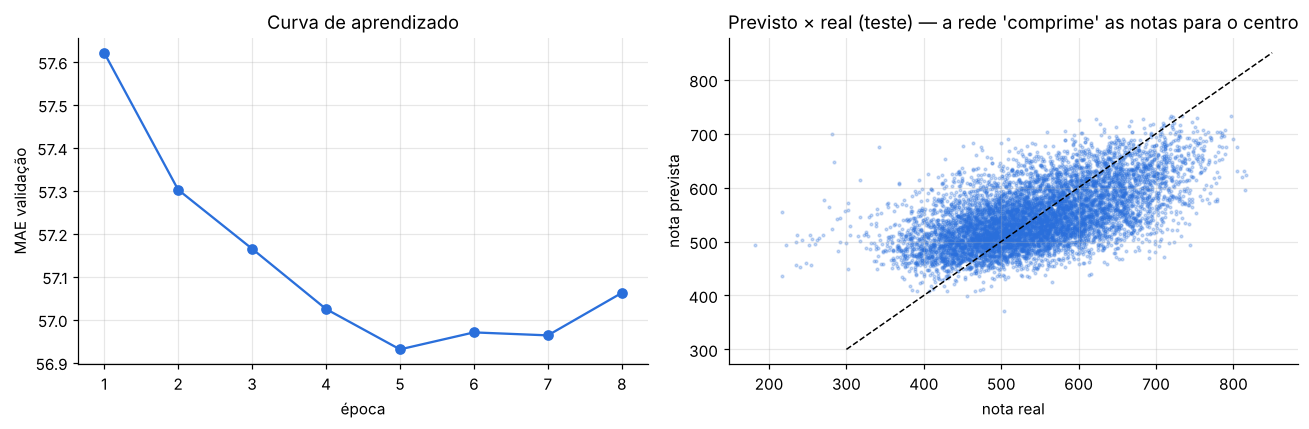

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(rede.hist) + 1), rede.hist, "o-", color=CORES[0])
axes[0].set_title("Curva de aprendizado"); axes[0].set_xlabel("época"); axes[0].set_ylabel("MAE validação")
s = np.random.default_rng(0).choice(len(i_te), 8000, replace=False)
axes[1].scatter(y_all[i_te][s], p_rede[s], s=3, alpha=.25, color=CORES[0])
axes[1].plot([300, 850], [300, 850], "k--", lw=1)
axes[1].set_xlabel("nota real"); axes[1].set_ylabel("nota prevista")
axes[1].set_title("Previsto × real (teste) — a rede 'comprime' as notas para o centro")
plt.tight_layout(); plt.show()

In [8]:
# Sensibilidade ao δ da Huber (escolha feita só na VALIDAÇÃO; o teste não entra aqui)
sd_tr = float(y_all[i_tr].std())
opcoes = {"δ = 15 pts": 15, "δ = 30 pts": 30, "δ = 45 pts": 45, f"δ = 1 desvio (≈{sd_tr:.0f} pts, versão anterior)": sd_tr}
sens = {}
for nome, d in opcoes.items():
    if d == DELTA_PTS:
        sens[nome] = min(rede.hist)          # já treinado acima
    else:
        sens[nome] = min(treinar_rede(X_all.iloc[i_tr], y_all[i_tr], X_all.iloc[i_va], y_all[i_va],
                                      delta_pts=d, verbose=False).hist)
pd.Series(sens, name="melhor MAE de validação").round(2).to_frame()


,melhor MAE de validação
δ = 15 pts,56.95
δ = 30 pts,56.93
δ = 45 pts,56.91
"δ = 1 desvio (≈89 pts, versão anterior)",56.90


**Sobre o δ da Huber.** Na validação, δ de 15, 30, 45 pontos ou 1 desvio dão MAE praticamente igual (diferenças
de centésimos de ponto, dentro do ruído do treino). Ou seja, o desempenho não decide a escolha. O critério é
conceitual: com δ = 30 pontos a perda passa a ser linear para erros grandes, alinhada com o MAE usado na parada
antecipada, e uma nota extrema não domina o gradiente. Com δ = 1 desvio (~90 pontos) a Huber se comportaria quase
como um MSE e não cumpriria o papel para o qual foi escolhida.

**Leitura.** A rede supera a média global e a regressão linear, mas **empata com o gradient boosting**
(MAE ~57,1 nos dois; R² ~0,35), agora com os dois parando pela **mesma validação**. Dois recados:
- o ganho sobre a linear é pequeno: a relação perfil → nota é em grande parte **aditiva**, com poucas interações
  para descobrir;
- o empate com o boosting é o resultado típico em **dados tabulares**: redes neurais não têm vantagem automática
  sobre árvores nesse tipo de dado. A escolha da rede aqui é didática; o teto de desempenho é dado pela
  **informação disponível**, não pelo modelo.

O R² mostra que o perfil socioeconômico
explica só uma parte da nota. O resto (esforço, escola, professor, sorte no dia…) **não está nos dados**.
O gráfico mostra a consequência: as previsões ficam **comprimidas** perto da média de cada perfil. Quem tirou
nota muito alta é subestimado, quem tirou nota muito baixa é superestimado.

Isso é esperado de qualquer regressor. O problema começa quando olhamos **para quem** isso acontece.

## 4. Experimento A — viés do modelo "bem treinado"

In [9]:
Gt = G.iloc[i_te].reset_index(drop=True)
yt, pt = y_all[i_te], p_rede

def tabela_grupo(g, y, p, grupos):
    d = pd.DataFrame({"g": grupos[g].values, "y": y, "p": p, "e": p - y})
    t = d.groupby("g").agg(n=("y", "size"), nota_real=("y", "mean"), nota_prevista=("p", "mean"),
                           MAE=("e", lambda e: e.abs().mean()), erro_medio=("e", "mean"))
    return t.reindex([o for o in ORDENS[g] if o in t.index]).round(1)

for g in ["Renda familiar", "Escola (EM)", "Cor/raça", "Região"]:
    print(f"\n=== {g} ==="); display(tabela_grupo(g, yt, pt, Gt))


=== Renda familiar ===


,n,nota_real,nota_prevista,MAE,erro_medio
g,,,,,
até 1 SM,19891,504.100006,501.700012,54.799999,-2.4
1–2 SM,15558,536.700012,535.799988,56.799999,-1.0
2–4 SM,11837,569.799988,571.200012,59.799999,1.4
4–7 SM,5210,603.000000,605.799988,59.500000,2.8
> 7 SM,5595,629.700012,636.700012,58.000000,6.9



=== Escola (EM) ===


,n,nota_real,nota_prevista,MAE,erro_medio
g,,,,,
Pública,17727,525.400024,527.400024,56.900002,2.0
Privada,4818,618.400024,605.500000,61.000000,-12.8
Não informou,35546,548.400024,549.400024,56.700001,1.0



=== Cor/raça ===


,n,nota_real,nota_prevista,MAE,erro_medio
g,,,,,
Branca,25345,573.500000,575.799988,57.700001,2.3
Amarela,940,540.900024,540.900024,56.000000,-0.0
Parda,24095,527.799988,526.299988,56.900002,-1.5
Preta,6766,520.299988,518.700012,55.400002,-1.6
Indígena,277,487.399994,487.200012,53.599998,-0.2
Não declarado,668,555.799988,548.299988,62.599998,-7.5



=== Região ===


,n,nota_real,nota_prevista,MAE,erro_medio
g,,,,,
Norte,6072,517.599976,514.799988,56.500000,-2.8
Nordeste,21466,532.900024,533.500000,57.500000,0.6
Centro-Oeste,4736,547.400024,547.200012,58.700001,-0.2
Sudeste,19431,568.099976,568.200012,56.700001,0.1
Sul,6386,559.500000,561.099976,56.400002,1.6


Na média de cada grupo o modelo parece "justo": o erro médio por grupo fica perto de zero, porque o grupo
está (direta ou indiretamente) nas entradas. Mas a média esconde o essencial. Vamos olhar **os melhores alunos**.

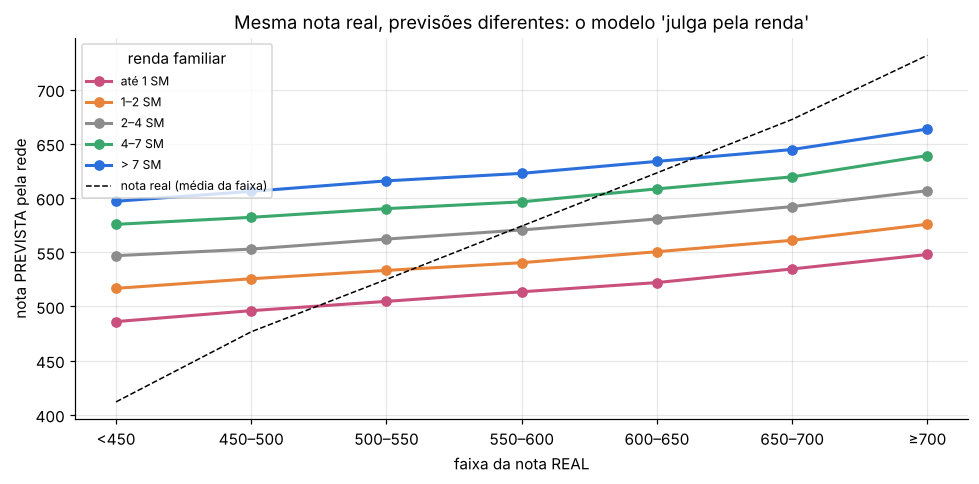

renda,até 1 SM,1–2 SM,2–4 SM,4–7 SM,> 7 SM
faixa_real,,,,,
<450,486.0,517.0,547.0,576.0,597.0
450–500,496.0,525.0,553.0,582.0,606.0
500–550,505.0,533.0,562.0,590.0,616.0
550–600,513.0,540.0,570.0,596.0,623.0
600–650,522.0,550.0,581.0,608.0,634.0
650–700,535.0,561.0,592.0,619.0,645.0
≥700,548.0,576.0,607.0,639.0,664.0


In [10]:
# Para cada faixa de nota REAL, qual nota o modelo prevê, separado por renda?
bins = [0, 450, 500, 550, 600, 650, 700, 1000]
rot = ["<450", "450–500", "500–550", "550–600", "600–650", "650–700", "≥700"]
d = pd.DataFrame({"renda": Gt["Renda familiar"], "faixa_real": pd.cut(yt, bins, labels=rot), "y": yt, "p": pt})
piv = d.pivot_table(index="faixa_real", columns="renda", values="p", aggfunc="mean")[ORD_RENDA]

fig, ax = plt.subplots(figsize=(9, 4.5))
for k, c in zip(ORD_RENDA, ["#c94f7c", "#e8833a", "#8c8c8c", "#3aa76d", "#2a6fdb"]):
    ax.plot(rot, piv[k].values, "o-", color=c, label=k, lw=2)
ax.plot(rot, d.groupby("faixa_real")["y"].mean().values, "k--", lw=1, label="nota real (média da faixa)")
ax.set_xlabel("faixa da nota REAL"); ax.set_ylabel("nota PREVISTA pela rede")
ax.set_title("Mesma nota real, previsões diferentes: o modelo 'julga pela renda'")
ax.legend(title="renda familiar", fontsize=8); plt.tight_layout(); plt.show()
piv.round(0)

In [11]:
# Simulação: usar a rede para selecionar os 10% "mais promissores" (ex.: programa de bolsas)
corte_real = np.quantile(yt, .90)
corte_prev = np.quantile(pt, .90)
d = pd.DataFrame({"Renda familiar": Gt["Renda familiar"], "Escola (EM)": Gt["Escola (EM)"],
                  "top_real": yt >= corte_real, "top_prev": pt >= corte_prev})

def recall_top(col):
    t = d[d.top_real].groupby(col)["top_prev"].mean().rename("% dos talentos reais que a rede seleciona")
    comp = d.groupby(col).agg(**{"% do grupo no top 10% REAL": ("top_real", "mean"),
                                 "% do grupo no top 10% PREVISTO": ("top_prev", "mean")})
    return (comp.join(t) * 100).reindex([o for o in ORDENS[col] if o in comp.index]).round(1)

print(f"Corte top 10%: nota real ≥ {corte_real:.0f}")
display(recall_top("Renda familiar")); display(recall_top("Escola (EM)"))
sel_real = d[d.top_real]["Renda familiar"].isin(["4–7 SM", "> 7 SM"]).mean()
sel_prev = d[d.top_prev]["Renda familiar"].isin(["4–7 SM", "> 7 SM"]).mean()
print(f"Renda > 4 SM é {d['Renda familiar'].isin(['4–7 SM','> 7 SM']).mean():.0%} dos candidatos, "
      f"{sel_real:.0%} do top 10% REAL e {sel_prev:.0%} dos selecionados pela REDE.")

Corte top 10%: nota real ≥ 668


,% do grupo no top 10% REAL,% do grupo no top 10% PREVISTO,% dos talentos reais que a rede seleciona
Renda familiar,,,
até 1 SM,2.1,0.2,3.7
1–2 SM,5.1,0.9,5.3
2–4 SM,12.2,7.8,24.5
4–7 SM,23.0,28.0,53.6
> 7 SM,34.9,58.1,77.8


,% do grupo no top 10% REAL,% do grupo no top 10% PREVISTO,% dos talentos reais que a rede seleciona
Escola (EM),,,
Pública,4.0,2.3,17.3
Privada,28.6,35.5,56.4
Não informou,10.5,10.4,44.9


Renda > 4 SM é 19% dos candidatos, 54% do top 10% REAL e 81% dos selecionados pela REDE.


**Resultado do Experimento A.**
- Para uma **mesma nota real alta**, a rede prevê nota bem menor para quem tem renda baixa: o aluno pobre que
  foi muito bem é tratado como "ponto fora da curva" e puxado para a média do seu grupo.
- Se a rede fosse usada para escolher os 10% mais promissores, **a maioria dos selecionados seria de alta renda**
  e só uma fração mínima dos talentos de baixa renda seria encontrada (veja o *recall* por faixa acima). Ela amplia uma desigualdade que já existe nas notas reais e torna **invisíveis os talentos de baixa
  renda**, que existem, mas não "parecem" com o perfil do topo.
- O tipo de escola **não** é entrada do modelo, e mesmo assim aparece um efeito: alunos de escola privada são
  **subestimados** em ~13 pontos, porque a escola explica parte da nota além da renda. Variável omitida também
  gera viés.
- O modelo não está "errado" estatisticamente: ele minimiza o erro médio. O viés é **consequência de prever
  um indivíduo pelas características do grupo**.

## 5. Experimento B — dados de treino enviesados

Agora o problema é **quem está no treino**. Duas situações realistas:

- **B1 — só alta renda:** uma empresa treina com dados de clientes de um cursinho caro (renda > 4 SM).
- **B2 — só Sul/Sudeste:** um modelo desenvolvido com dados de SP/RJ/MG/ES/PR/SC/RS e usado no país inteiro.

Para separar o efeito do **viés** do efeito do **tamanho da amostra**, cada modelo enviesado é comparado com um
**modelo de controle** treinado com o **mesmo número** de pessoas sorteadas aleatoriamente.

[B1 só renda > 4 SM] treino enviesado: 51,129 | controle aleatório: 51,129


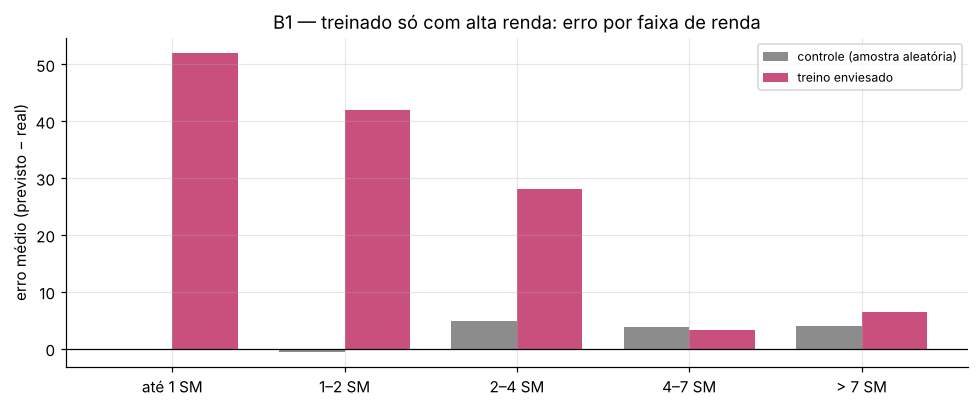

,nota real,erro médio — controle,erro médio — enviesado,MAE — controle,MAE — enviesado
Renda familiar,,,,,
até 1 SM,504.100006,-0.2,52.0,55.400002,74.599998
1–2 SM,536.700012,-0.6,42.0,57.500000,68.800003
2–4 SM,569.799988,4.9,28.0,60.700001,64.699997
4–7 SM,603.000000,3.9,3.3,60.500000,60.099998
> 7 SM,629.700012,4.0,6.4,58.900002,58.299999


In [12]:
def experimento(mascara_treino, nome):
    tr = i_tr[mascara_treino[i_tr]]
    va = i_va[mascara_treino[i_va]]
    rng = np.random.default_rng(SEED)
    tr_ctrl = rng.choice(i_tr, len(tr), replace=False)
    va_ctrl = rng.choice(i_va, len(va), replace=False)
    print(f"[{nome}] treino enviesado: {len(tr):,} | controle aleatório: {len(tr_ctrl):,}")
    m_vies = treinar_rede(X_all.iloc[tr], y_all[tr], X_all.iloc[va], y_all[va], verbose=False)
    m_ctrl = treinar_rede(X_all.iloc[tr_ctrl], y_all[tr_ctrl], X_all.iloc[va_ctrl], y_all[va_ctrl], verbose=False)
    return m_vies(X_all.iloc[i_te]), m_ctrl(X_all.iloc[i_te])

def comparar(p_vies, p_ctrl, g, titulo):
    t = pd.DataFrame({
        "nota real": pd.Series(yt).groupby(Gt[g]).mean(),
        "erro médio — controle": pd.Series(p_ctrl - yt).groupby(Gt[g]).mean(),
        "erro médio — enviesado": pd.Series(p_vies - yt).groupby(Gt[g]).mean(),
        "MAE — controle": pd.Series(np.abs(p_ctrl - yt)).groupby(Gt[g]).mean(),
        "MAE — enviesado": pd.Series(np.abs(p_vies - yt)).groupby(Gt[g]).mean(),
    }).reindex([o for o in ORDENS[g] if o in Gt[g].unique()])
    fig, ax = plt.subplots(figsize=(9, 3.8))
    x = np.arange(len(t)); w = .38
    ax.bar(x - w/2, t["erro médio — controle"], w, label="controle (amostra aleatória)", color="#8c8c8c")
    ax.bar(x + w/2, t["erro médio — enviesado"], w, label="treino enviesado", color="#c94f7c")
    ax.axhline(0, color="k", lw=.8); ax.set_xticks(x, t.index)
    ax.set_ylabel("erro médio (previsto − real)"); ax.set_title(titulo); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return t.round(1)

alta_renda = raw.Q006.isin(list("HIJKLMNOPQ")).values
p_b1, p_b1c = experimento(alta_renda, "B1 só renda > 4 SM")
comparar(p_b1, p_b1c, "Renda familiar", "B1 — treinado só com alta renda: erro por faixa de renda")

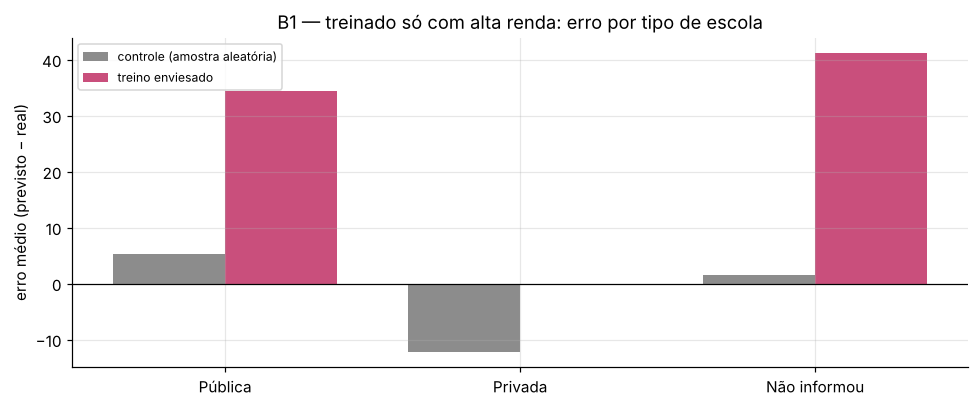

,nota real,erro médio — controle,erro médio — enviesado,MAE — controle,MAE — enviesado
Escola (EM),,,,,
Pública,525.400024,5.3,34.299999,57.599998,65.800003
Privada,618.400024,-12.2,-0.200000,61.299999,59.200001
Não informou,548.400024,1.5,41.200001,57.500000,70.599998


In [13]:
comparar(p_b1, p_b1c, "Escola (EM)", "B1 — treinado só com alta renda: erro por tipo de escola")

[B2 só Sul/Sudeste] treino enviesado: 121,360 | controle aleatório: 121,360


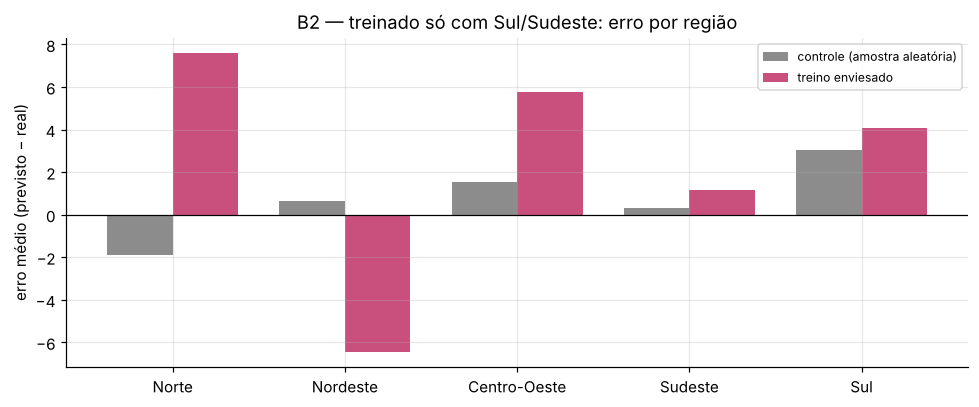

,nota real,erro médio — controle,erro médio — enviesado,MAE — controle,MAE — enviesado
Região,,,,,
Norte,517.599976,-1.9,7.6,56.500000,58.099998
Nordeste,532.900024,0.6,-6.4,57.799999,59.000000
Centro-Oeste,547.400024,1.5,5.8,58.700001,59.799999
Sudeste,568.099976,0.3,1.2,57.000000,56.900002
Sul,559.500000,3.0,4.1,56.900002,56.599998


In [14]:
sul_sudeste = raw.SG_UF_PROVA.map(REGIAO).isin(["Sudeste", "Sul"]).values
p_b2, p_b2c = experimento(sul_sudeste, "B2 só Sul/Sudeste")
comparar(p_b2, p_b2c, "Região", "B2 — treinado só com Sul/Sudeste: erro por região")

In [15]:
# Resumo do Experimento B
resumo = pd.DataFrame({
    "MAE geral — controle": [mean_absolute_error(yt, p_b1c), mean_absolute_error(yt, p_b2c)],
    "MAE geral — enviesado": [mean_absolute_error(yt, p_b1), mean_absolute_error(yt, p_b2)],
    "R² — controle": [r2_score(yt, p_b1c), r2_score(yt, p_b2c)],
    "R² — enviesado": [r2_score(yt, p_b1), r2_score(yt, p_b2)],
}, index=["B1 só alta renda", "B2 só Sul/Sudeste"]).round(3)
resumo

,MAE geral — controle,MAE geral — enviesado,R² — controle,R² — enviesado
B1 só alta renda,57.847,68.160,0.331,0.094
B2 só Sul/Sudeste,57.354,58.005,0.341,0.330


**Resultado do Experimento B.**
- **B1:** a rede que só viu alunos de alta renda **superestima sistematicamente** os grupos de baixa renda e de
  escola pública. Ela nunca viu como a falta de recursos se relaciona com a nota, então **extrapola** o padrão
  de quem tem recursos. O controle, com o mesmo tamanho de amostra, não tem esse problema: **o culpado é a
  composição dos dados, não a quantidade**.
- **B2:** o efeito é **bem menor** do que se esperaria: o erro médio no Nordeste e no Norte muda só alguns pontos
  (o Nordeste passa a ser subestimado), e o MAE geral quase não piora. A rede não aprende o embedding das UFs
  ausentes, mas a **renda e a escolaridade dos pais já carregam quase toda a informação** que a UF traria.
  Conclusão interessante: o viés vem muito mais de **quem** está no treino (perfil socioeconômico) do que de
  **onde** essas pessoas moram, desde que a diversidade de renda esteja representada.
- Em ambos os casos, **a validação feita no mesmo recorte enviesado não denunciaria o problema**: só a
  avaliação por grupo na população completa revela o viés.

Note que um viés de **superestimar** também é dano: se o modelo for usado para alocar reforço escolar, os grupos
superestimados **deixam de receber ajuda**.

## 6. Experimento C — e se o modelo souber mais sobre a pessoa e o lugar?

Até aqui a rede só viu variáveis que existem **também em 2025** (para poder aplicar o modelo lá). Mas o arquivo de
2023 tem mais informação, e dá para **ligar dados externos pelo código IBGE do município da prova**.

**Bloco 1: escola e trajetória (do próprio arquivo de 2023)**
- tipo de escola do ensino médio (pública/privada), dependência administrativa (federal/estadual/municipal/privada)
  e localização (urbana/rural) da escola;
- língua estrangeira escolhida (inglês/espanhol);
- ano de conclusão do ensino médio.

⚠️ Tipo de escola, dependência e localização **só vêm preenchidos para quem estava concluindo o ensino médio em
2023** (~39% / ~27%). Para os demais, "não informou" vira uma categoria própria, que acaba significando
"já concluiu o EM".

**Bloco 2: contexto do município (dados externos, script `02b_contexto_municipal.py`)**
- Atlas do Desenvolvimento Humano (PNUD/IPEA/FJP, Censo 2010): IDHM e seus componentes, Gini, renda per capita,
  % de extremamente pobres, % de analfabetos, % de adultos com médio e superior completos, taxa de urbanização;
- população estimada (2021), se é capital e distância até a capital do estado.

Limitações: é o município **da prova**, não necessariamente o de residência (é um bom *proxy*); e o Atlas é de 2010.

**Pergunta:** com mais informação o modelo fica mais preciso? E fica **mais justo** com o aluno de baixa renda que vai bem?

1,749 municípios de prova na amostra | 14 variáveis municipais


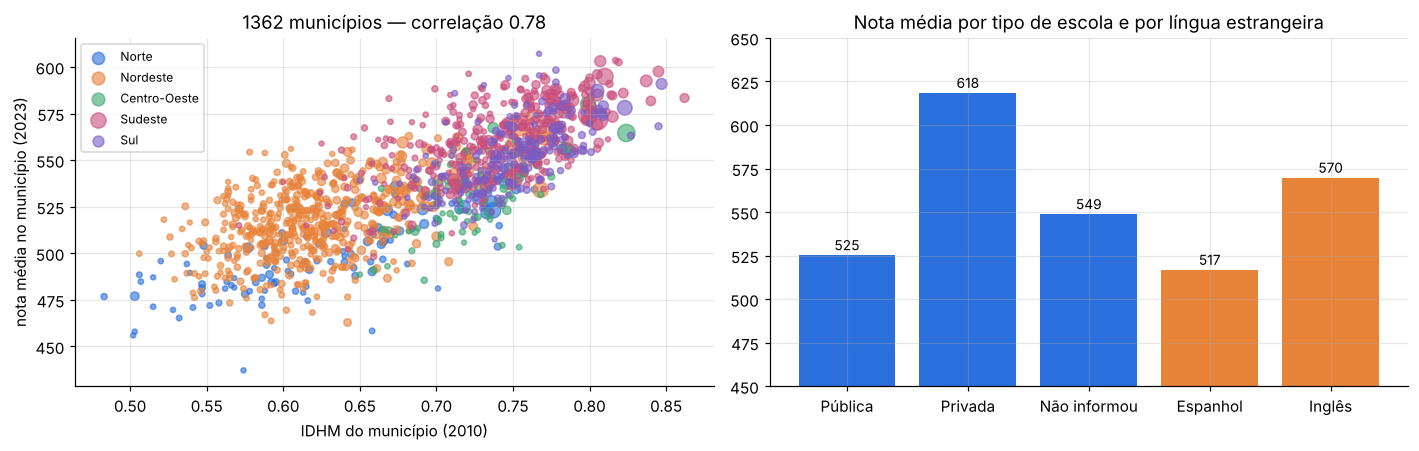

In [16]:
ctx = pd.read_csv(DADOS + "contexto_municipal.csv")
NUM_MUN = [c for c in ctx.columns if c not in ("CO_MUNICIPIO", "NOME_MUNICIPIO", "UF")]
mun = (raw[["CO_MUNICIPIO_PROVA", "SG_UF_PROVA"]].assign(CO_MUNICIPIO_PROVA=lambda d: d.CO_MUNICIPIO_PROVA.astype(int))
       .merge(ctx, left_on="CO_MUNICIPIO_PROVA", right_on="CO_MUNICIPIO", how="left"))
for c in NUM_MUN:   # 5 municípios criados após 2010 não estão no Atlas: mediana da UF
    mun[c] = mun[c].fillna(mun.groupby("SG_UF_PROVA")[c].transform("median"))
N_mun = mun[NUM_MUN].values.astype(np.float32)
print(f"{raw.CO_MUNICIPIO_PROVA.nunique():,} municípios de prova na amostra | {len(NUM_MUN)} variáveis municipais")

X_esc = X_all.copy()
X_esc["TP_ESCOLA"] = raw.TP_ESCOLA.values
X_esc["DEPENDENCIA_ESC"] = raw.TP_DEPENDENCIA_ADM_ESC.fillna("NA").values
X_esc["LOCALIZACAO_ESC"] = raw.TP_LOCALIZACAO_ESC.fillna("NA").values
X_esc["LINGUA"] = raw.TP_LINGUA.values
X_esc["ANO_CONCLUIU"] = raw.TP_ANO_CONCLUIU.values

# Relação no nível do município: IDHM x nota média (municípios com >= 50 candidatos na amostra)
m = (pd.DataFrame({"mun": raw.CO_MUNICIPIO_PROVA.values, "nota": y_all, "IDHM": mun.IDHM.values,
                   "regiao": raw.SG_UF_PROVA.map(REGIAO).values})
     .groupby("mun").agg(nota=("nota", "mean"), n=("nota", "size"), IDHM=("IDHM", "first"), regiao=("regiao", "first")))
m = m[m.n >= 50]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for reg, c in zip(ORDENS["Região"], CORES):
    s = m[m.regiao == reg]
    axes[0].scatter(s.IDHM, s.nota, s=np.sqrt(s.n) * 1.5, alpha=.6, color=c, label=reg)
axes[0].set_xlabel("IDHM do município (2010)"); axes[0].set_ylabel("nota média no município (2023)")
axes[0].set_title(f"{len(m)} municípios — correlação {m.IDHM.corr(m.nota):.2f}"); axes[0].legend(fontsize=8)
lg = pd.Series(y_all).groupby(raw.TP_LINGUA.map({"0": "Inglês", "1": "Espanhol"}).values).mean()
esc = pd.Series(y_all).groupby(G["Escola (EM)"]).mean().reindex(ORDENS["Escola (EM)"])
vals = pd.concat([esc, lg]); cores = [CORES[0]] * 3 + [CORES[1]] * 2
axes[1].bar(vals.index, vals.values, color=cores); axes[1].set_ylim(450, 650)
for i, v in enumerate(vals.values): axes[1].text(i, v + 3, f"{v:.0f}", ha="center", fontsize=9)
axes[1].set_title("Nota média por tipo de escola e por língua estrangeira")
plt.tight_layout(); plt.show()

In [17]:
def treinar_gbm(Xc, N=None):
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)
    A = enc.fit_transform(Xc.iloc[i_tr])
    mask = np.ones(A.shape[1], dtype=bool)
    if N is not None:
        A = np.hstack([A, N[i_tr]]); mask = np.r_[mask, np.zeros(N.shape[1], dtype=bool)]
    V = enc.transform(Xc.iloc[i_va])
    if N is not None:
        V = np.hstack([V, N[i_va]])
    # mesma validação da rede (i_va) para a parada antecipada
    g = HistGradientBoostingRegressor(categorical_features=mask, max_iter=1000, learning_rate=0.08,
                                      max_leaf_nodes=63, early_stopping=True, n_iter_no_change=20,
                                      random_state=SEED).fit(A, y_all[i_tr], X_val=V, y_val=y_all[i_va])
    T = enc.transform(Xc.iloc[i_te])
    if N is not None:
        T = np.hstack([T, N[i_te]])
    return g, g.predict(T), T

cenarios = {}
t0 = time.time()
cenarios["C0 · só questionário"] = {"rede": p_rede, "gbm": p_gbm}

r1 = treinar_rede(X_esc.iloc[i_tr], y_all[i_tr], X_esc.iloc[i_va], y_all[i_va], verbose=False)
cenarios["C1 · + escola, língua, ano de conclusão"] = {"rede": r1(X_esc.iloc[i_te]), "gbm": treinar_gbm(X_esc)[1]}

r2 = treinar_rede(X_esc.iloc[i_tr], y_all[i_tr], X_esc.iloc[i_va], y_all[i_va],
                  N_tr=N_mun[i_tr], N_va=N_mun[i_va], verbose=False)
gbm2, p_gbm2, T_gbm2 = treinar_gbm(X_esc, N_mun)
cenarios["C2 · + contexto municipal"] = {"rede": r2(X_esc.iloc[i_te], N_mun[i_te]), "gbm": p_gbm2}
print(f"6 modelos em {time.time()-t0:.0f}s")

desemp = pd.DataFrame({k: {"MAE rede": mean_absolute_error(yt, v["rede"]), "R² rede": r2_score(yt, v["rede"]),
                           "MAE boosting": mean_absolute_error(yt, v["gbm"]), "R² boosting": r2_score(yt, v["gbm"])}
                       for k, v in cenarios.items()}).T.round(3)
desemp

6 modelos em 116s


,MAE rede,R² rede,MAE boosting,R² boosting
C0 · só questionário,57.097,0.346,57.068,0.351
"C1 · + escola, língua, ano de conclusão",55.399,0.383,55.341,0.389
C2 · + contexto municipal,55.162,0.390,55.013,0.396


In [18]:
def auditoria(p):
    d = pd.DataFrame({"y": yt, "p": p, "renda": Gt["Renda familiar"], "escola": Gt["Escola (EM)"]})
    top = d[d.y >= 700]
    baixa, alta = top[top.renda == "até 1 SM"].p.mean(), top[top.renda == "> 7 SM"].p.mean()
    corte_r, corte_p = np.quantile(yt, .9), np.quantile(p, .9)
    talentos_pobres = d[(d.y >= corte_r) & d.renda.isin(["até 1 SM", "1–2 SM"])]
    return {
        "Previsão p/ nota real ≥700 — até 1 SM": baixa,
        "Previsão p/ nota real ≥700 — > 7 SM": alta,
        "Diferença (pontos)": alta - baixa,
        "% talentos ≤2 SM que a rede seleciona (top 10%)": 100 * (talentos_pobres.p >= corte_p).mean(),
        "Erro médio — escola pública": (d.p - d.y)[d.escola == "Pública"].mean(),
        "Erro médio — escola privada": (d.p - d.y)[d.escola == "Privada"].mean(),
    }

aud = pd.DataFrame({k: auditoria(v["rede"]) for k, v in cenarios.items()}).T.round(1)
aud

,Previsão p/ nota real ≥700 — até 1 SM,Previsão p/ nota real ≥700 — > 7 SM,Diferença (pontos),% talentos ≤2 SM que a rede seleciona (top 10%),Erro médio — escola pública,Erro médio — escola privada
C0 · só questionário,547.7,663.6,115.8,4.8,2.0,-12.8
"C1 · + escola, língua, ano de conclusão",560.7,670.4,109.7,7.2,-1.7,7.3
C2 · + contexto municipal,568.5,668.4,99.9,9.2,0.1,7.8


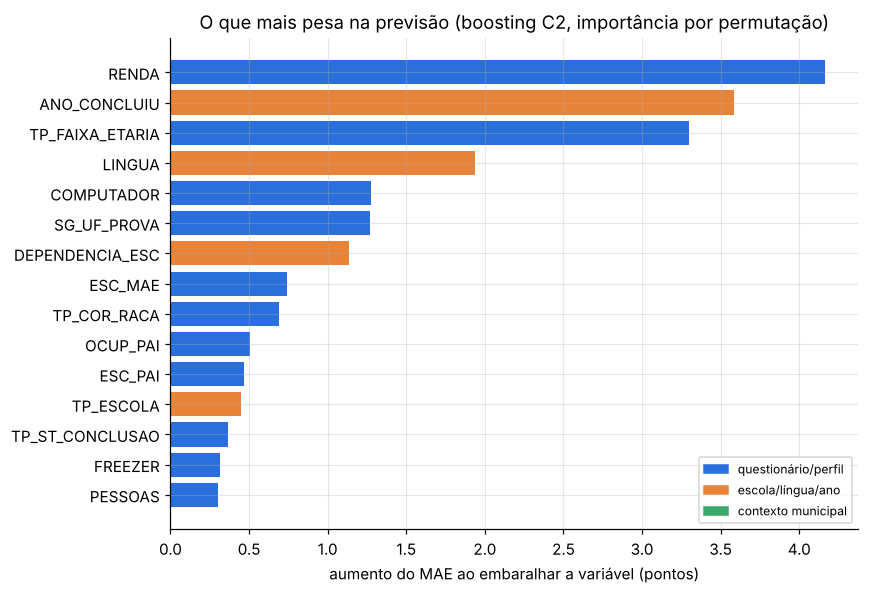

In [19]:
from sklearn.inspection import permutation_importance
nomes = list(X_esc.columns) + NUM_MUN
amostra = np.random.default_rng(SEED).choice(len(i_te), 15000, replace=False)
imp = permutation_importance(gbm2, T_gbm2[amostra], yt[amostra], scoring="neg_mean_absolute_error",
                             n_repeats=3, random_state=SEED, n_jobs=1)
imp = pd.Series(imp.importances_mean, index=nomes).sort_values(ascending=True).tail(15)
bloco = lambda n: CORES[2] if n in NUM_MUN else CORES[1] if n in X_esc.columns[len(FEATURES):] else CORES[0]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(imp.index, imp.values, color=[bloco(n) for n in imp.index])
ax.set_xlabel("aumento do MAE ao embaralhar a variável (pontos)")
ax.set_title("O que mais pesa na previsão (boosting C2, importância por permutação)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=CORES[0], label="questionário/perfil"), Patch(color=CORES[1], label="escola/língua/ano"),
                   Patch(color=CORES[2], label="contexto municipal")], fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

**Resultado do Experimento C.**
- **Precisão:** escola, língua e ano de conclusão elevam o R² de ~0,35 para ~0,39 (MAE −1,7 ponto). O contexto
  municipal acrescenta pouco (R² +0,007). Rede e boosting continuam empatados em todos os cenários.
- **Por que o município ajuda tão pouco, se a correlação IDHM × nota média é 0,78?** Porque essa correlação é
  **entre médias de municípios** (nível ecológico). Para prever um **indivíduo**, a renda e a escolaridade da família
  dele já dizem quase tudo o que o IDHM diria; dentro de qualquer município há alunos de todas as notas. Cuidado com
  a **falácia ecológica**: correlação forte entre grupos não implica poder preditivo forte para pessoas.
  Na importância por permutação as variáveis municipais aparecem baixas também porque são muito correlacionadas
  entre si e com a UF: embaralhar uma delas não tira a informação, que continua nas outras.
- **Ano de conclusão e língua estrangeira** entram entre as mais importantes: quem faz a prova anos depois de
  terminar o EM tende a ter nota menor, e escolher inglês está associado a mais recursos.
- **Justiça:** com mais informação o viés **diminui, mas não some**. Para alunos com nota real ≥ 700, a diferença
  entre a previsão para "até 1 SM" e para "> 7 SM" cai de ~116 para ~100 pontos, e a fração de talentos de baixa
  renda (≤ 2 SM) que a rede colocaria no top 10% sobe de ~5% para ~9%. O erro de −13 pontos para escola privada
  desaparece quando o modelo passa a saber a escola. **Mais variáveis de contexto ajudam a reduzir o viés de
  variável omitida, mas não resolvem o problema de prever um indivíduo pela média do seu grupo.**

## 7. Do diagnóstico à ação — onde agir antes da prova?

Os experimentos mostraram que **usar o modelo para selecionar pessoas é perigoso**. Mas o mesmo modelo pode ser útil
de outro jeito: **para decidir onde investir ajuda**. Se o modelo "subestima" quem é pobre, ele aponta exatamente
para onde o apoio faz falta.

Três perguntas práticas:
1. **Em que área da prova** a desigualdade é maior (e onde um programa de reforço rende mais)?
2. **Que escolas** levam alunos pobres a superar o esperado?
3. **Que municípios** têm alunos com o mesmo perfil, mas resultados muito diferentes? Quem supera o esperado
   ("desvio positivo") e quem fica abaixo?

**Método.** Para cada candidato calculamos a **nota esperada para o perfil** (só questionário, modelo C0) e o
**resíduo** = nota real − nota esperada. Para que o resíduo de todo mundo seja "fora da amostra", usamos
*validação cruzada* (5 dobras) com o gradient boosting, que empatou com a rede e treina em segundos.
Resíduo positivo = foi **melhor do que o perfil socioeconômico prevê**.

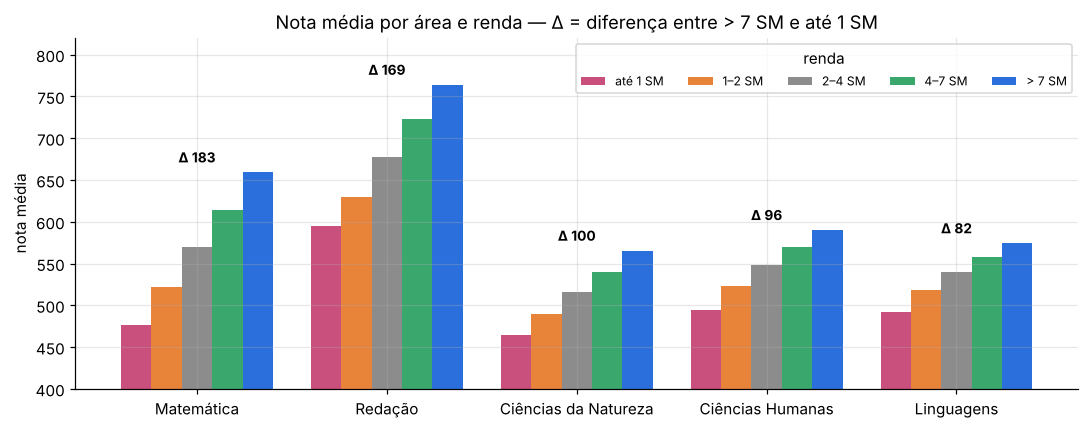

,Matemática,Redação,Ciências da Natureza,Ciências Humanas,Linguagens
até 1 SM,476.0,595.0,465.0,494.0,492.0
1–2 SM,522.0,630.0,490.0,523.0,519.0
2–4 SM,570.0,678.0,516.0,548.0,540.0
4–7 SM,614.0,724.0,540.0,570.0,558.0
> 7 SM,659.0,764.0,565.0,590.0,574.0


In [20]:
# 7.1 — Em que área a desigualdade é maior?
AREAS = {"NU_NOTA_MT": "Matemática", "NU_NOTA_REDACAO": "Redação", "NU_NOTA_CN": "Ciências da Natureza",
         "NU_NOTA_CH": "Ciências Humanas", "NU_NOTA_LC": "Linguagens"}
t = raw.groupby(G["Renda familiar"].values)[list(AREAS)].mean().reindex(ORD_RENDA).rename(columns=AREAS)
gap = (t.loc["> 7 SM"] - t.loc["até 1 SM"]).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(gap)); w = .16
for k, (faixa, c) in enumerate(zip(ORD_RENDA, ["#c94f7c", "#e8833a", "#8c8c8c", "#3aa76d", "#2a6fdb"])):
    ax.bar(x + (k - 2) * w, t.loc[faixa, gap.index], w, color=c, label=faixa)
for i, g in enumerate(gap.values):
    ax.text(i, t[gap.index[i]].max() + 12, f"Δ {g:.0f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x, gap.index); ax.set_ylim(400, 820); ax.set_ylabel("nota média")
ax.set_title("Nota média por área e renda — Δ = diferença entre > 7 SM e até 1 SM")
ax.legend(title="renda", fontsize=8, ncol=5, loc="upper right"); plt.tight_layout(); plt.show()
t.round(0)

In [21]:
# 7.2 — Resíduo fora da amostra (nota real − esperada pelo perfil)
from sklearn.model_selection import cross_val_predict
A_all = OrdinalEncoder().fit_transform(X_all)
gcv = HistGradientBoostingRegressor(categorical_features=np.ones(A_all.shape[1], dtype=bool),
                                    max_iter=200, learning_rate=0.1, max_leaf_nodes=63, random_state=SEED)
esperada = cross_val_predict(gcv, A_all, y_all, cv=5)
residuo = y_all - esperada
print(f"MAE validação cruzada: {mean_absolute_error(y_all, esperada):.1f}")

baixa = G["Renda familiar"].isin(["até 1 SM", "1–2 SM"]).values
DEP = {"1": "Federal", "2": "Estadual", "3": "Municipal", "4": "Privada"}
d = pd.DataFrame({"res": residuo, "nota": y_all, "dep": raw.TP_DEPENDENCIA_ADM_ESC.map(DEP).values,
                  "lingua": raw.TP_LINGUA.map({"0": "Inglês", "1": "Espanhol"}).values})[baixa]
tab_dep = d.dropna(subset=["dep"]).groupby("dep").agg(alunos=("res", "size"), nota_media=("nota", "mean"),
                                                     acima_do_esperado=("res", "mean"))
tab_lng = d.groupby("lingua").agg(alunos=("res", "size"), nota_media=("nota", "mean"), acima_do_esperado=("res", "mean"))
print("Alunos com renda ≤ 2 SM concluindo o EM em 2023 — por dependência da escola:")
display(tab_dep[tab_dep.alunos >= 300].round(1).sort_values("acima_do_esperado", ascending=False))
print("Alunos com renda ≤ 2 SM — por língua estrangeira escolhida:")
display(tab_lng.round(1))

MAE validação cruzada: 57.1
Alunos com renda ≤ 2 SM concluindo o EM em 2023 — por dependência da escola:


,alunos,nota_media,acima_do_esperado
dep,,,
Federal,3376,579.500000,52.6
Privada,5626,580.000000,33.3
Municipal,480,513.200012,-4.5
Estadual,45906,509.799988,-5.2


Alunos com renda ≤ 2 SM — por língua estrangeira escolhida:


,alunos,nota_media,acima_do_esperado
lingua,,,
Espanhol,122898,503.899994,-7.6
Inglês,112517,534.500000,8.7


**Leitura.**
- **Matemática e Redação** concentram a desigualdade: a diferença entre os extremos de renda é cerca do dobro das
  outras áreas. A Redação, em especial, é **altamente treinável** (5 competências fixas, melhora com prática e
  correção) e vale o mesmo peso de uma área inteira: é o candidato natural para programas de reforço de baixo custo.
- Alunos de baixa renda de **escolas federais** (Institutos Federais) ficam bem **acima** do esperado para o seu
  perfil, enquanto os de escola estadual ficam um pouco abaixo. ⚠️ Parte disso é **seleção** (os IFs têm prova de
  ingresso), então não é um efeito causal puro, mas é um sinal forte que merece investigação.
- Entre alunos pobres, quem escolhe **inglês** supera o esperado e quem escolhe espanhol fica abaixo. ⚠️ Isso
  **não** significa que trocar de língua aumenta a nota: quem escolhe inglês provavelmente já tinha mais preparo.
  **Correlação não é causa**, e isso define o limite do que um modelo preditivo pode recomendar.

844 municípios com ≥ 100 alunos na amostra | desvio-padrão real entre municípios ≈ 8.7 pontos
Correlação entre as duas metades sorteadas: 0.62 (quanto mais perto de 1, mais o ranking é sinal e não acaso)


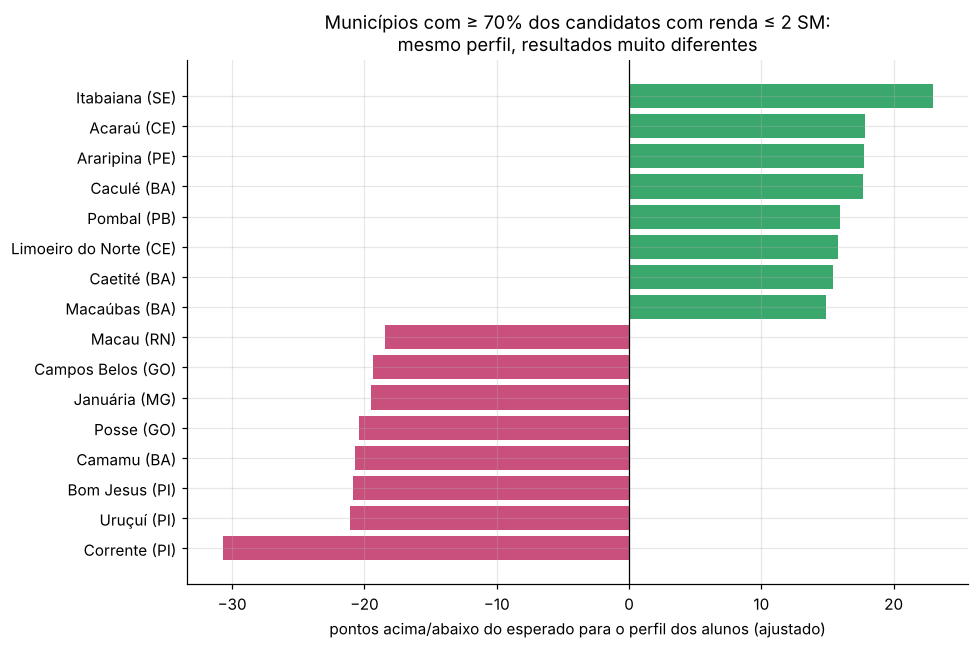

,NOME_MUNICIPIO,UF,alunos,pct_baixa_renda,residuo,residuo_ajustado
mun,,,,,,
2802908,Itabaiana,SE,476,0.83,26.54,22.94
2300200,Acaraú,CE,158,0.85,25.73,17.81
2601102,Araripina,PE,302,0.86,22.43,17.74
2905008,Caculé,BA,194,0.87,24.15,17.66
2512101,Pombal,PB,213,0.87,22.03,15.93
2307601,Limoeiro do Norte,CE,239,0.81,19.74,15.79
2905206,Caetité,BA,271,0.83,19.53,15.43
2919801,Macaúbas,BA,141,0.84,23.40,14.89
2807105,Simão Dias,SE,146,0.89,20.29,14.35


In [22]:
# 7.3 — Municípios: quem supera e quem fica abaixo do esperado para o perfil dos seus alunos
ctx_nomes = pd.read_csv(DADOS + "contexto_municipal.csv", usecols=["CO_MUNICIPIO", "NOME_MUNICIPIO", "UF"])
dm = pd.DataFrame({"mun": raw.CO_MUNICIPIO_PROVA.astype(int).values, "res": residuo, "baixa": baixa})
m = dm.groupby("mun").agg(alunos=("res", "size"), residuo=("res", "mean"), var=("res", "var"),
                          pct_baixa_renda=("baixa", "mean"))
m = m[m.alunos >= 100].join(ctx_nomes.set_index("CO_MUNICIPIO"))

# Encolhimento bayesiano empírico: médias de poucos alunos são ruidosas, então são "puxadas" para zero
# proporcionalmente à sua incerteza. tau2 = variância real entre municípios; sigma2/n = ruído de cada média.
ruido = m["var"] / m.alunos
tau2 = max(m.residuo.var() - ruido.mean(), 1e-6)
m["residuo_ajustado"] = m.residuo * tau2 / (tau2 + ruido)

# Confiabilidade: sorteia metade dos alunos de cada município e compara com a outra metade
rng = np.random.default_rng(SEED)
dm["metade"] = rng.integers(0, 2, len(dm))
meias = dm[dm.mun.isin(m.index)].groupby(["mun", "metade"]).res.mean().unstack()
conf = meias[0].corr(meias[1])
print(f"{len(m)} municípios com ≥ 100 alunos na amostra | desvio-padrão real entre municípios ≈ {np.sqrt(tau2):.1f} pontos")
print(f"Correlação entre as duas metades sorteadas: {conf:.2f} (quanto mais perto de 1, mais o ranking é sinal e não acaso)")

pobres = m[m.pct_baixa_renda >= .7].sort_values("residuo_ajustado")
sel = pd.concat([pobres.head(8), pobres.tail(8)])
fig, ax = plt.subplots(figsize=(9, 6))
cores = ["#c94f7c" if v < 0 else "#3aa76d" for v in sel.residuo_ajustado]
ax.barh([f"{n} ({u})" for n, u in zip(sel.NOME_MUNICIPIO, sel.UF)], sel.residuo_ajustado, color=cores)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("pontos acima/abaixo do esperado para o perfil dos alunos (ajustado)")
ax.set_title("Municípios com ≥ 70% dos candidatos com renda ≤ 2 SM:\nmesmo perfil, resultados muito diferentes")
plt.tight_layout(); plt.show()
cols = ["NOME_MUNICIPIO", "UF", "alunos", "pct_baixa_renda", "residuo", "residuo_ajustado"]
display(pobres.tail(10)[cols][::-1].round(2))

In [23]:
# Ceará em destaque
ce = m[m.UF == "CE"].sort_values("residuo_ajustado", ascending=False)
print(f"Ceará: {len(ce)} municípios com ≥ 100 alunos na amostra")
display(pd.concat([ce.head(6), ce.tail(4)])[cols].round(2))

Ceará: 66 municípios com ≥ 100 alunos na amostra


,NOME_MUNICIPIO,UF,alunos,pct_baixa_renda,residuo,residuo_ajustado
mun,,,,,,
2300200,Acaraú,CE,158,0.85,25.73,17.81
2307601,Limoeiro do Norte,CE,239,0.81,19.74,15.79
2302800,Canindé,CE,261,0.87,17.82,13.72
2307254,Jijoca de Jericoacoara,CE,113,0.92,21.21,12.38
2306306,Itapajé,CE,162,0.88,18.47,12.26
2303105,Cariré,CE,132,0.89,16.84,11.08
2302107,Baturité,CE,177,0.94,-17.94,-12.79
2304707,Granja,CE,136,0.95,-20.80,-13.50
2301109,Aracati,CE,222,0.86,-18.83,-15.27


**Leitura.** Municípios com **o mesmo perfil socioeconômico** chegam a ter dezenas de pontos de diferença na nota
média. O ajuste bayesiano reduz o peso de municípios com poucos alunos, e o teste das duas metades mostra quanto
do ranking é **sinal real**: o restante é acaso, por isso um ranking assim deve ser confirmado com **mais de um ano**
de dados antes de qualquer decisão.

### Que problema isso resolve?

| Produto | Pergunta que responde | Quem usaria |
|---|---|---|
| **Focalização de reforço** | Com orçamento limitado, em quais municípios e escolas um programa de Matemática e Redação tem mais impacto? | Secretarias de educação, prefeituras, cursinhos populares |
| **Valor agregado** | Quantos pontos os alunos tiraram **acima do esperado para o seu perfil**? (Métrica mais justa que a nota média ou a taxa de aprovação, que favorecem quem já recebe alunos ricos) | Secretarias (avaliação de escolas), fundações que financiam cursinhos, famílias |
| **Desvio positivo** | O que fazem os municípios e escolas pobres que superam o esperado, e como replicar nos que ficam abaixo? | Gestores públicos, pesquisadores, ONGs |

**Uso responsável.** Aqui o modelo **prioriza ajuda, não seleciona pessoas**. Nesse uso, o viés encontrado no
Experimento A deixa de ser um dano: o modelo é "pessimista" justamente sobre quem mais precisa de apoio. A decisão
final continua sendo da política pública, e a avaliação de impacto real exige **dados de antes e depois** (ou um
grupo de comparação), não só um modelo preditivo.

## 8. Aplicação em 2025 — validação agregada por UF

Em 2025 não há como ligar perfil e nota de uma pessoa, mas há como comparar **médias por UF**:
1. aplicamos a rede (treinada em 2023) nos questionários harmonizados de 2025 (amostra de 15% de `PARTICIPANTES`);
2. calculamos a **média prevista por UF**;
3. comparamos com a **média real por UF** de `RESULTADOS_2025` (só quem fez todas as provas).

⚠️ **Limitação:** `PARTICIPANTES` inclui **inscritos que faltaram** (não dá para filtrar presença sem a chave),
enquanto a média real só inclui presentes. Como faltosos tendem a ter perfil de menor renda, a média prevista tende
a ficar **um pouco abaixo** da real. O que importa aqui é se a rede **ordena** as UFs corretamente.

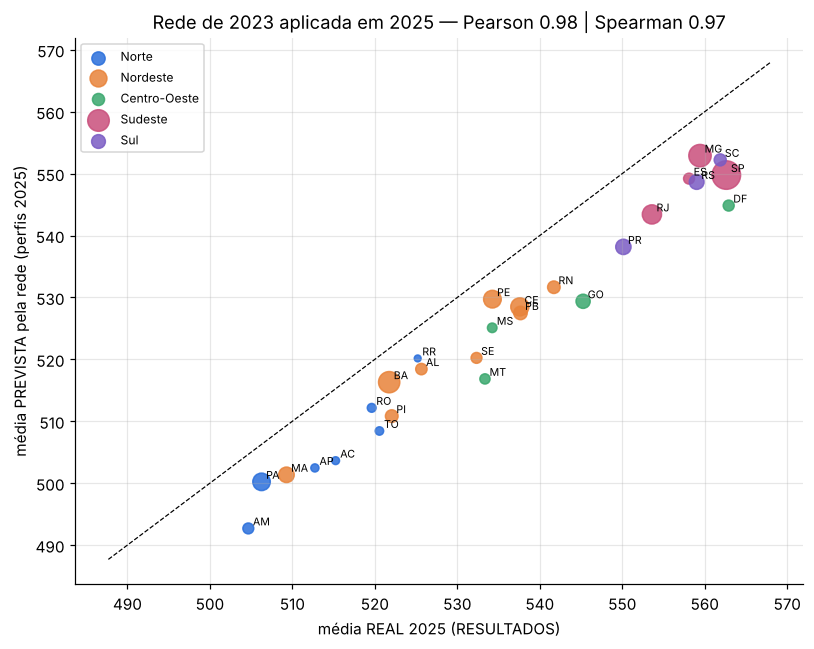

Viés médio (previsto − real): -10.1 pontos


,count,media_real,media_prevista,regiao
SG_UF_PROVA,,,,
DF,54804,562.9,544.799988,Centro-Oeste
SP,498528,562.6,549.799988,Sudeste
SC,70312,561.9,552.200012,Sul
MG,298730,559.4,552.900024,Sudeste
RS,116989,559.0,548.599976,Sul
ES,53498,558.1,549.200012,Sudeste
RJ,214021,553.6,543.400024,Sudeste
PR,128057,550.1,538.200012,Sul
GO,106299,545.3,529.400024,Centro-Oeste


In [24]:
p25 = pd.read_csv(DADOS + "enem2025_participantes_amostra.csv.gz", dtype=str)
X25 = harmonizar_2025(p25).fillna("NA")[FEATURES]
p25["PREVISTA"] = rede(X25)

real_uf = pd.read_csv(DADOS + "enem2025_media_real_por_uf.csv", index_col=0)
uf = real_uf.join(p25.groupby("SG_UF_PROVA")["PREVISTA"].mean().rename("media_prevista"))
uf["regiao"] = uf.index.map(REGIAO)

from scipy.stats import spearmanr, pearsonr
r_p, r_s = pearsonr(uf.media_real, uf.media_prevista)[0], spearmanr(uf.media_real, uf.media_prevista)[0]
fig, ax = plt.subplots(figsize=(7.5, 6))
for k, (reg, c) in enumerate(zip(ORDENS["Região"], CORES)):
    s = uf[uf.regiao == reg]
    ax.scatter(s.media_real, s.media_prevista, s=s["count"] / 1500 + 15, color=c, label=reg, alpha=.85)
for u, r in uf.iterrows():
    ax.annotate(u, (r.media_real, r.media_prevista), fontsize=7, xytext=(3, 2), textcoords="offset points")
lo, hi = uf[["media_real", "media_prevista"]].min().min() - 5, uf[["media_real", "media_prevista"]].max().max() + 5
ax.plot([lo, hi], [lo, hi], "k--", lw=.8)
ax.set_xlabel("média REAL 2025 (RESULTADOS)"); ax.set_ylabel("média PREVISTA pela rede (perfis 2025)")
ax.set_title(f"Rede de 2023 aplicada em 2025 — Pearson {r_p:.2f} | Spearman {r_s:.2f}")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"Viés médio (previsto − real): {(uf.media_prevista - uf.media_real).mean():.1f} pontos")
uf.sort_values("media_real", ascending=False).round(1).head(27)

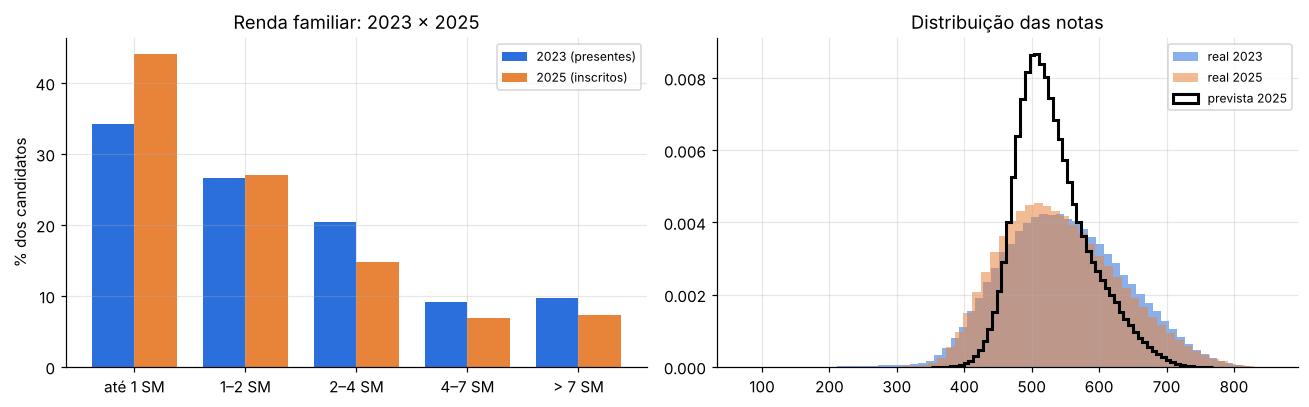

Média real 2023: 547.5 | real 2025: 541.5 | prevista 2025: 531.2
Desvio-padrão real 2025: 85.8 | previsto 2025: 54.1  (compressão)


In [25]:
# O perfil dos inscritos mudou entre 2023 e 2025? (renda em faixas de salário mínimo — comparáveis)
r23 = faixa_renda(raw.Q006.values).value_counts(normalize=True).reindex(ORD_RENDA)
r25 = faixa_renda(p25.Q007.fillna("B").values).value_counts(normalize=True).reindex(ORD_RENDA)
n25 = pd.read_csv(DADOS + "enem2025_notas_amostra.csv.gz")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(5); w = .38
axes[0].bar(x - w/2, r23 * 100, w, label="2023 (presentes)", color=CORES[0])
axes[0].bar(x + w/2, r25 * 100, w, label="2025 (inscritos)", color=CORES[1])
axes[0].set_xticks(x, ORD_RENDA); axes[0].set_ylabel("% dos candidatos"); axes[0].legend(fontsize=8)
axes[0].set_title("Renda familiar: 2023 × 2025")
axes[1].hist(y_all, bins=60, density=True, alpha=.55, label="real 2023", color=CORES[0])
axes[1].hist(n25.NOTA_MEDIA, bins=60, density=True, alpha=.55, label="real 2025", color=CORES[1])
axes[1].hist(p25.PREVISTA, bins=60, density=True, histtype="step", lw=2, label="prevista 2025", color="k")
axes[1].set_title("Distribuição das notas"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Média real 2023: {y_all.mean():.1f} | real 2025: {n25.NOTA_MEDIA.mean():.1f} | prevista 2025: {p25.PREVISTA.mean():.1f}")
print(f"Desvio-padrão real 2025: {n25.NOTA_MEDIA.std():.1f} | previsto 2025: {p25.PREVISTA.std():.1f}  (compressão)")

**Leitura.** A rede treinada em 2023 consegue **ordenar as UFs** de 2025 a partir apenas dos perfis
(correlação ≈ 0,98 entre média prevista e real), com um deslocamento de ~10 pontos para baixo, coerente com a
inclusão dos faltosos. Isso
mostra que ela capturou a estrutura socioeconômica por trás das notas. Ao mesmo tempo:
- a distribuição prevista é **muito mais estreita** que a real: a rede não "vê" os extremos;
- o perfil dos inscritos muda de ano para ano (*data drift*) e o próprio **questionário mudou**, o que exigiu
  harmonização manual. Um modelo em produção precisaria ser **monitorado e re-treinado**.

## 9. Conclusões

1. **É possível prever** a nota do ENEM a partir do perfil socioeconômico com erro médio de algumas dezenas de pontos,
   a rede neural com embeddings empata com o gradient boosting e supera a regressão linear. Mas a maior parte da variação **não é explicada** pelo perfil.
2. **Precisão média não é justiça.** O modelo "bem treinado" prevê bem a média de cada grupo, mas, para a mesma nota
   real, **prevê notas menores para alunos de baixa renda**. Usado para selecionar talentos, ele os tornaria invisíveis.
3. **Os dados de treino definem o viés.** Treinado só com alta renda ou só com Sul/Sudeste, o modelo erra
   sistematicamente os grupos ausentes, e **a validação no mesmo recorte não denuncia o problema**. O controle com
   amostra aleatória do mesmo tamanho mostra que o problema é a **composição**, não o volume.
4. **Mais informação ajuda, mas não resolve.** Escola, língua, ano de conclusão e contexto municipal (IDHM, Gini,
   renda per capita…) sobem o R² para ~0,39 e reduzem o viés contra talentos de baixa renda (diferença de
   previsão cai de ~116 para ~100 pontos), mas a rede continua "puxando" esses alunos para a média do grupo.
   O contexto municipal tem correlação forte com a nota **média** do município (0,78), mas pouco poder para prever
   **pessoas** (falácia ecológica).
5. **Do diagnóstico à ação.** O uso responsável do modelo é **focalizar ajuda**, não selecionar pessoas. Matemática e
   Redação concentram a desigualdade (diferenças de ~180 e ~170 pontos entre os extremos de renda). Municípios com o
   mesmo perfil têm resultados bem diferentes, e o resíduo (nota real − esperada) vira uma métrica de **valor
   agregado** para encontrar quem supera o esperado e para onde direcionar reforço.
6. **Lição prática:** antes de usar um modelo para decisões sobre pessoas, avaliar o erro **por grupo** e
   **condicionado ao resultado real**, auditar a representatividade do treino e lembrar que variáveis como renda e
   UF funcionam como *proxies* de desigualdade estrutural.
7. **LGPD e ciência de dados:** a separação dos microdados a partir de 2024 protege os participantes, mas também
   impede esse tipo de auditoria com dados recentes. É um *trade-off* real entre privacidade e transparência.